Chosen example images:


,image,err_HOGRF,err_5featXGB,fp_HOGRF,fn_HOGRF,fp_5featXGB,fn_5featXGB,delta_err
0,CIMG0137.JPG,32,7,0,32,0,7,25
1,CIMG1270.JPG,40,12,2,38,1,11,28


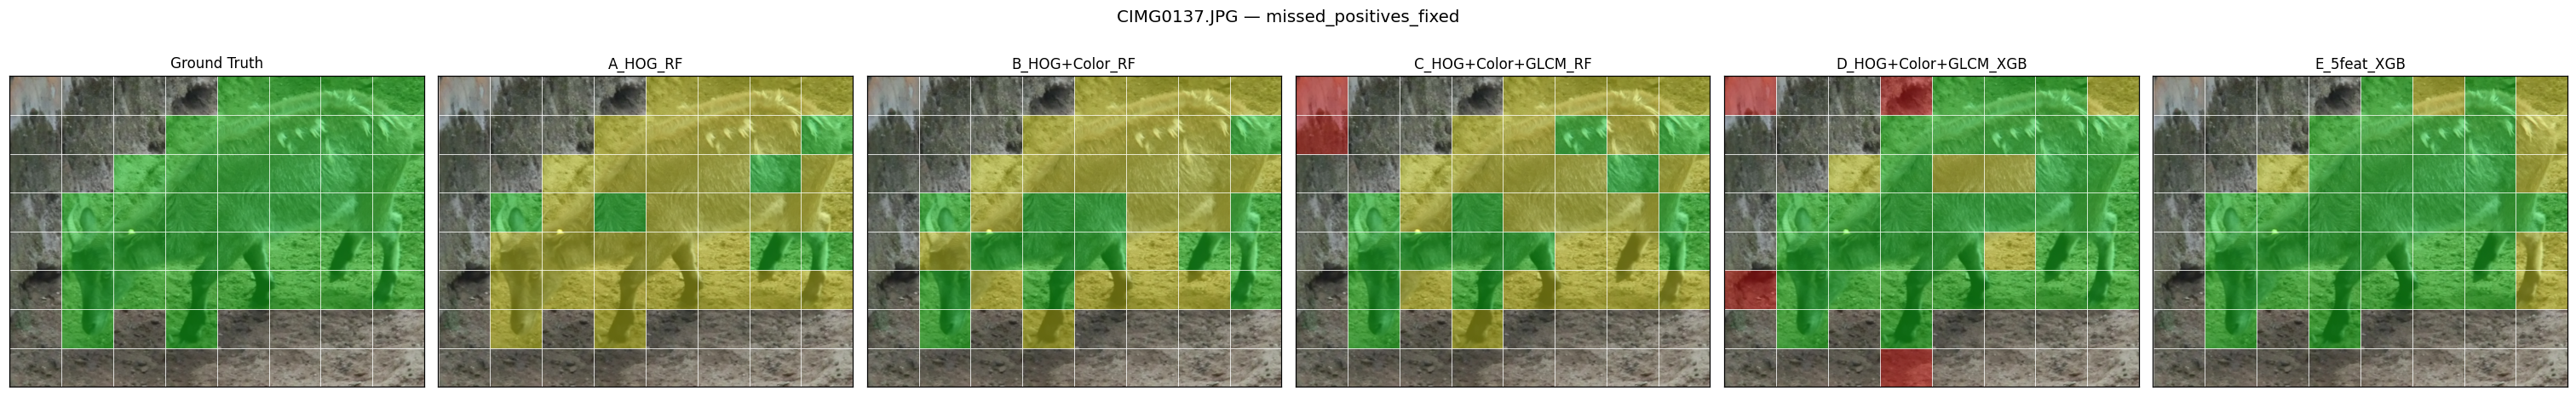

Saved: /home/pratyush/Desktop/DS_Project/outputs/qualitative/missed_positives_fixed_CIMG0137_JPG.png


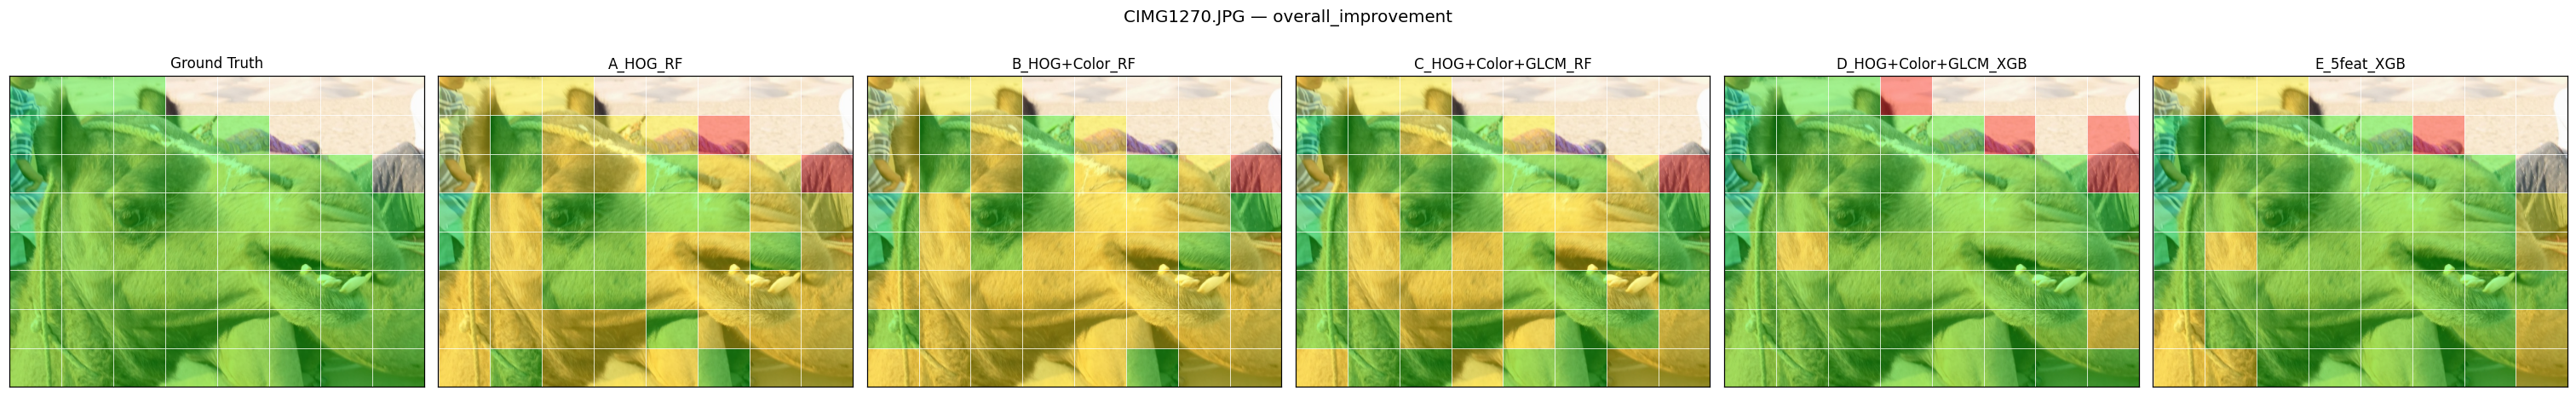

Saved: /home/pratyush/Desktop/DS_Project/outputs/qualitative/overall_improvement_CIMG1270_JPG.png
Summary saved: /home/pratyush/Desktop/DS_Project/outputs/qualitative/chosen_examples_summary.csv


In [4]:
# === Qualitative Comparison Panels: GT vs all models on selected "improvement" images ===
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --------- CONFIG ---------
BASE = "/home/pratyush/Desktop/DS_Project"
IMG_DIR_A = f"{BASE}/data/label_image"       # preferred for visuals
IMG_DIR_B = f"{BASE}/data/preprocessed"      # fallback; guaranteed 800x600
GT_CSV    = f"{BASE}/data/splits/test_labels.csv"  # adjust if your test_labels.csv lives elsewhere

# If your test_labels.csv is somewhere else, uncomment & set explicitly:
# GT_CSV = "/home/pratyush/Desktop/DS_Project/test_labels.csv"

RES_DIR   = f"{BASE}/results"
OUT_DIR   = f"{BASE}/outputs/qualitative"
os.makedirs(OUT_DIR, exist_ok=True)

# models to compare (left→right order in plots) — tweak names/paths if needed
MODEL_CSVS = {
    "A_HOG_RF":                        os.path.join(RES_DIR, "test_predictions_hog_rf.csv"),
    "B_HOG+Color_RF":                  os.path.join(RES_DIR, "test_predictions_hog_color_rf.csv"),
    "C_HOG+Color+GLCM_RF":             os.path.join(RES_DIR, "test_predictions_hog_color_glcm_rf.csv"),
    "D_HOG+Color+GLCM_XGB":            os.path.join(RES_DIR, "test_predictions_hog_color_glcm_xgb.csv"),
    "E_5feat_XGB":                     os.path.join(RES_DIR, "test_predictions_hog_color_glcm_lbp_pos_xgb.csv"),
}

# Grid geometry
GRID_W, GRID_H = 8, 8
W, H = 800, 600
CW, CH = W // GRID_W, H // GRID_H

def get_image_path(img_name):
    pA = os.path.join(IMG_DIR_A, img_name)
    pB = os.path.join(IMG_DIR_B, img_name)
    return pA if os.path.exists(pA) else pB

# --------- LOADERS ---------
def load_gt(gt_csv):
    df = pd.read_csv(gt_csv)
    # tolerate a flat CSV (image, c01..c64)
    cols = [f"c{i:02d}" for i in range(1, 65)]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing label columns in GT: {missing[:5]} ...")
    gt_map = {}
    for _, r in df.iterrows():
        gt_map[r["image"]] = r[cols].to_numpy(int)
    return gt_map

def load_preds(pred_csv):
    df = pd.read_csv(pred_csv)
    if "image" not in df.columns or "cell_id" not in df.columns:
        raise ValueError(f"{pred_csv} must contain 'image' and 'cell_id' columns")
    pred_col = "pred_smooth" if "pred_smooth" in df.columns else "pred"
    if pred_col not in df.columns:
        raise ValueError(f"{pred_csv} must contain 'pred' or 'pred_smooth'")
    # order by c01..c64
    df["cell_index"] = df["cell_id"].str.extract(r"c(\d{2})").astype(int) - 1
    pred_map = {}
    for img, g in df.groupby("image"):
        g = g.sort_values("cell_index")
        pred_map[img] = g[pred_col].to_numpy(int)
    return pred_map

gt = load_gt(GT_CSV)
preds = {name: load_preds(path) for name, path in MODEL_CSVS.items()}

# only keep images present in GT and all models
common_imgs = set(gt.keys())
for m in preds.values():
    common_imgs &= set(m.keys())
common_imgs = sorted(common_imgs)
if not common_imgs:
    raise RuntimeError("No overlapping images between GT and model prediction CSVs. Check filenames.")

# --------- METRICS/SCORING ---------
def counts(y_true, y_pred):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    err = fp + fn
    return tp, tn, fp, fn, err

rows = []
for img in common_imgs:
    y  = gt[img]
    yA = preds["A_HOG_RF"][img]
    yE = preds["E_5feat_XGB"][img]
    tpA, tnA, fpA, fnA, errA = counts(y, yA)
    tpE, tnE, fpE, fnE, errE = counts(y, yE)
    rows.append((img, errA, errE, fpA, fnA, fpE, fnE, errA-errE))
sel_df = pd.DataFrame(rows, columns=["image","err_HOGRF","err_5featXGB","fp_HOGRF","fn_HOGRF","fp_5featXGB","fn_5featXGB","delta_err"])

# Pick 3 illustrative cases:
# 1) many FNs in HOG+RF that improve in 5feat_XGB
miss_case   = sel_df[(sel_df.fn_HOGRF >= 2) & (sel_df.fp_HOGRF <= 1)].sort_values("delta_err", ascending=False).head(1)
# 2) many FPs in HOG+RF that get cleaned in 5feat_XGB
extra_case  = sel_df[(sel_df.fp_HOGRF >= 2) & (sel_df.fn_HOGRF <= 1)].sort_values("delta_err", ascending=False).head(1)
# 3) largest overall error reduction
overall_case= sel_df.sort_values("delta_err", ascending=False).head(1)

chosen = pd.concat([miss_case, extra_case, overall_case]).drop_duplicates(subset=["image"]).reset_index(drop=True)
print("Chosen example images:")
display(chosen)

# --------- DRAWING ---------
def overlay(ax, img_path, y_true, y_pred, title):
    im = plt.imread(img_path)
    ax.imshow(im)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=11)
    for idx in range(64):
        r, c = divmod(idx, GRID_W)
        x0, y0 = c*CW, r*CH
        t, p = y_true[idx], y_pred[idx]
        if   t==1 and p==1: face=(0,1,0,0.35)   # TP green
        elif t==0 and p==1: face=(1,0,0,0.35)   # FP red
        elif t==1 and p==0: face=(1,1,0,0.35)   # FN yellow
        else:                face=(0,0,0,0.0)   # TN transparent
        rect = patches.Rectangle((x0,y0), CW,CH,
                                 linewidth=0.6, edgecolor=(1,1,1,0.6),
                                 facecolor=face)
        ax.add_patch(rect)

def render_compare(img_name, tag):
    y = gt[img_name]
    fig, axes = plt.subplots(1, len(MODEL_CSVS)+1, figsize=(4.6*(len(MODEL_CSVS)+1), 4.6), dpi=110)
    # GT first
    overlay(axes[0], get_image_path(img_name), y, y, "Ground Truth")
    # Each model
    for i, (mname, pmap) in enumerate(MODEL_CSVS.items(), start=1):
        yhat = preds[mname][img_name]
        overlay(axes[i], get_image_path(img_name), y, yhat, mname)
    fig.suptitle(f"{img_name} — {tag}", fontsize=13)
    fig.tight_layout()
    outp = os.path.join(OUT_DIR, f"{tag}_{img_name.replace('.', '_')}.png")
    plt.savefig(outp, bbox_inches="tight")
    plt.show()
    print("Saved:", outp)

# Render all chosen cases
for _, row in chosen.iterrows():
    img = row["image"]
    if row["fn_HOGRF"] >= 2 and row["fp_HOGRF"] <= 1:
        tag = "missed_positives_fixed"
    elif row["fp_HOGRF"] >= 2 and row["fn_HOGRF"] <= 1:
        tag = "extra_positives_cleaned"
    else:
        tag = "overall_improvement"
    render_compare(img, tag)

# Also save the chosen list for your report
chosen_out = os.path.join(OUT_DIR, "chosen_examples_summary.csv")
chosen.to_csv(chosen_out, index=False)
print("Summary saved:", chosen_out)
